<p style="font-size: 26pt;">Dual-Use Technology Governance Analysis for AI Research Sprint</p>
<p style="font-size: 16pt;">Analyzing how treaties manage civilian-military boundaries across technology lifecycles</p>

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

weapons_df = pd.read_csv('/workspaces/amc-research-sprint-lh_gl/duplicates_result.csv', encoding='latin-1')
merged_df = pd.read_csv('/workspaces/amc-research-sprint-lh_gl/mergedresults.csv', encoding='latin-1')
df = pd.read_csv('/workspaces/amc-research-sprint-lh_gl/mergedresults.csv', encoding='latin-1')

CREATE "SCORES"

In [ ]:
ban_cols = [c for c in df.columns if c.startswith('ban_')]
restriction_cols = [c for c in df.columns if 'restriction' in c]

df["ban_score"] = df[ban_cols].sum(axis=1)
df["restriction_score"] = df[restriction_cols].sum(axis=1)

df["ban_intensity"] = df["ban_score"] / len(ban_cols) if len(ban_cols) > 0 else 0
df["restriction_intensity"] = df["restriction_score"] / len(restriction_cols) if len(restriction_cols) > 0 else 0

df["total_regulation"] = df["ban_score"] + df["restriction_score"]

<p>FILTER DUAL-USE ONLY</p>
<p>!!!! Since we're using the mergedresults.csv, the same weapon will appear multiple times if regulated by multiple treaties

In [97]:
DUAL_USE_COL = "dual_use"

if DUAL_USE_COL in df.columns:
    df_dual = df[df[DUAL_USE_COL] == 1].copy()
else:
    print(f"Warning: '{DUAL_USE_COL}' column not found. Using full dataset.")
    df_dual = df.copy()

print("Dual-use dataset shape:", df_dual.shape)

Dual-use dataset shape: (22, 70)


GROUP BY WEAPON CATEGORY ("item")

In [98]:
item_analysis = df_dual.groupby("item")[[
    "ban_intensity",
    "restriction_intensity"
]].mean().sort_values("restriction_intensity", ascending=False)

print("\n=== ITEM ANALYSIS (Dual-Use) ===")
print(item_analysis.head(20))


=== ITEM ANALYSIS (Dual-Use) ===
                                                    ban_intensity  \
item                                                                
toxin                                                         0.0   
microbial/other biological agent                              0.0   
schedule 2 chemical                                           0.0   
schedule 3 chemical                                           0.0   
fissile material                                              0.0   
(category 2) arms and ammunition capable of use...            0.0   
category iv(aircrafts and aircrafts compenents)               0.0   
explosive                                                     0.0   
aircrafts (incl. their parts and engines)                     0.0   
dual-use goods and technologie                                0.0   
nuclear material                                              0.0   
space launch vehicle                                          0.0   


REGIONAL ANALYSIS

The agreement-specific region:
0.Africa
1.Asia
2.Europe
3.The Americas
4.Antarctica

In [99]:
# adapted to the analysis will cover only treaties that are region specific
if "region" in df_dual.columns:
    if (df_dual["region"] == 1).any():
        if "region_specific" in df_dual.columns:
            region_analysis = df_dual.groupby("region_specific")[[
                "ban_intensity",
                "restriction_intensity"
            ]].mean().sort_values("restriction_intensity", ascending=False)

            print("\n=== REGIONAL ANALYSIS (Dual-Use) ===")
            print(region_analysis)

            # Ratio analysis
            region_analysis["ban_to_restriction_ratio"] = (
                region_analysis["ban_intensity"] /
                (region_analysis["restriction_intensity"] + 1e-5)
            )

            print("\n=== REGIONAL GOVERNANCE STYLE ===")
            print(region_analysis.sort_values("ban_to_restriction_ratio", ascending=False))
    else:
        print("No region-specific agreements")


=== REGIONAL ANALYSIS (Dual-Use) ===
                 ban_intensity  restriction_intensity
region_specific                                      
0.0                        0.0                0.37500
1.0                        0.0                0.37500
3.0                        0.0                0.15625
2.0                        0.0                0.12500

=== REGIONAL GOVERNANCE STYLE ===
                 ban_intensity  restriction_intensity  \
region_specific                                         
0.0                        0.0                0.37500   
1.0                        0.0                0.37500   
3.0                        0.0                0.15625   
2.0                        0.0                0.12500   

                 ban_to_restriction_ratio  
region_specific                            
0.0                                   0.0  
1.0                                   0.0  
3.0                                   0.0  
2.0                                   0.

CLASSIFY GOVERNANCE TYPE

In [100]:
def classify_regulation(row):
    if row["ban_intensity"] > 0.7:
        return "Ban-heavy"
    elif row["restriction_intensity"] > 0.7:
        return "Restriction-heavy"
    elif row["ban_intensity"] > 0 and row["restriction_intensity"] > 0:
        return "Mixed"
    else:
        return "Weak/None"

df_dual["regulation_type"] = df_dual.apply(classify_regulation, axis=1)

if "region" in df_dual.columns:
    if (df_dual["region"] == 1).any():
        regime_types = pd.crosstab(
            df_dual["region_specific"],
            df_dual["regulation_type"],
            normalize="index"
        )

    print("\n=== REGULATION TYPE DISTRIBUTION ===")
    print(regime_types)


=== REGULATION TYPE DISTRIBUTION ===
regulation_type  Weak/None
region_specific           
0.0                    1.0
1.0                    1.0
2.0                    1.0
3.0                    1.0


TREATY-LEVEL STRENGTH

In [101]:
MERGE_KEY = "agreement_id"

treaty_strength = df_dual.groupby(MERGE_KEY)[[
    "ban_intensity",
    "restriction_intensity"
]].mean()

treaty_strength["total_strength"] = (
    treaty_strength["ban_intensity"] +
    treaty_strength["restriction_intensity"]
)

print("\n=== TOP TREATIES (Dual-Use Governance Strength) ===")
print(treaty_strength.sort_values("total_strength", ascending=False).head(20))


=== TOP TREATIES (Dual-Use Governance Strength) ===
              ban_intensity  restriction_intensity  total_strength
agreement_id                                                      
310                     0.0                  0.625           0.625
130                     0.0                  0.625           0.625
340003                  0.0                  0.375           0.375
210001                  0.0                  0.375           0.375
210                     0.0                  0.375           0.375
90                      0.0                  0.375           0.375
290                     0.0                  0.375           0.375
330                     0.0                  0.375           0.375
340                     0.0                  0.375           0.375
25                      0.0                  0.250           0.250
370                     0.0                  0.250           0.250
8                       0.0                  0.125           0.125
70       

<p style="font-size: 16pt;color:red;">Visualization</p>

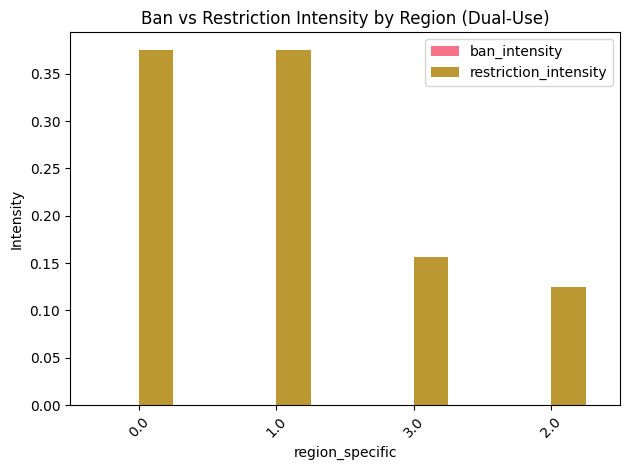

In [133]:
if "region" in df_dual.columns:
    region_analysis[["ban_intensity", "restriction_intensity"]].plot(kind="bar")
    plt.title("Ban vs Restriction Intensity by Region (Dual-Use)")
    plt.ylabel("Intensity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

REGULATORY DENSITY


=== REGULATORY DENSITY (Top Items) ===
item
fissile material                                                                                            7
nuclear material                                                                                            3
aircrafts (incl. their parts and engines)                                                                   1
category iv(aircrafts and aircrafts compenents)                                                             1
dual-use goods and technologie                                                                              1
(category 2) arms and ammunition capable of use both for military and other purpose                         1
explosive                                                                                                   1
instruments for use on aircraft (incl. wireless apparatus and photographic or cinematographic apparatus)    1
laser                                                                      

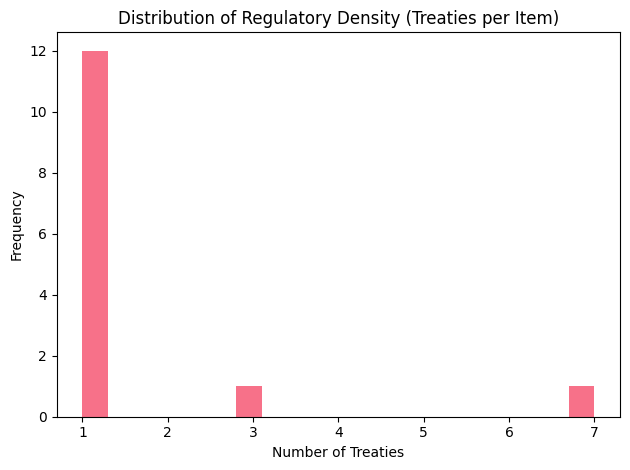

In [135]:
if MERGE_KEY in df_dual.columns:
    density = df_dual.groupby("item")[MERGE_KEY].nunique().sort_values(ascending=False)

    print("\n=== REGULATORY DENSITY (Top Items) ===")
    print(density.head(20))

    # Plot
    density.plot(kind="hist", bins=20)
    plt.title("Distribution of Regulatory Density (Treaties per Item)")
    plt.xlabel("Number of Treaties")
    plt.tight_layout()
    plt.show()


FRAGMENTATION

In [137]:
if "region" in df_dual.columns:
    fragmentation_region = df_dual.groupby("item")["region_specific"].nunique().sort_values(ascending=False)

    print("\n=== FRAGMENTATION (Regions per Item) ===")
    print(fragmentation_region.head(20))


# B. Normative fragmentation (variance across treaties)
fragmentation_variance = df_dual.groupby("item")[[
    "ban_intensity",
    "restriction_intensity"
]].std().sort_values("ban_intensity", ascending=False)

print("\n=== FRAGMENTATION (Variance across treaties) ===")
print(fragmentation_variance.head(20))


=== FRAGMENTATION (Regions per Item) ===
item
fissile material                                                                                            2
aircrafts (incl. their parts and engines)                                                                   1
explosive                                                                                                   1
instruments for use on aircraft (incl. wireless apparatus and photographic or cinematographic apparatus)    1
nuclear material                                                                                            1
(category 2) arms and ammunition capable of use both for military and other purpose                         0
category iv(aircrafts and aircrafts compenents)                                                             0
dual-use goods and technologie                                                                              0
laser                                                                    

CORRELATION ANALYSIS

<p style="font-size: 26pt;color:red;">Dual-use technologies analysis</p>

Add lifecycle restriction indicators

Identify potential dual-use technologies based on known patterns

In [102]:
def classify_dual_use_potential(item_text, weapon_definition=None):
    """
    Classify technologies by dual-use potential
    Returns: 'High', 'Medium', 'Low', or 'Military-Only'
    """
    if pd.isna(item_text):
        return 'Unknown'
    
    item_lower = str(item_text).lower()
    
    # High dual-use potential (technologies with clear civilian applications)
    high_dual_use = [
        'enrichment', 'centrifuge', 'reactor', 'uranium', 'plutonium',
        'chemical precursor', 'biological agent', 'computer', 'software',
        'satellite', 'rocket', 'missile technology', 'delivery system',
        'nuclear material', 'isotope'
    ]
    
    # Medium dual-use potential
    medium_dual_use = [
        'launcher', 'guidance', 'navigation', 'communication',
        'radar', 'sensor', 'detection', 'monitoring'
    ]
    
    # Military-only indicators
    military_only = [
        'nuclear weapon', 'warhead', 'bomb', 'explosive device',
        'icbm', 'slbm', 'heavy bomber', 'small arms', 'weapons','weapon',
        'missile',
        'missiles',
        'munition',
        'icbms',
        'icbm',
        'slbms',
        'abm',
        'asbm',
        'war',
        'warhead',
        'warheads',
        'mine',
        'mines',
        'bomber',
        'tank',
        'combat',
        'attack',
        'warship',
        'booby trap',
        'artillery',
        'heavy cruiser',
        'light cruiser',
        'destroyer',
        'firearm',
        'ammunition',
        'gun',
        'guns',
        'armed forces',
        'air force',
        'navy'
    ]
    
    # Check categories
    for term in military_only:
        if term in item_lower:
            return 'Military-Only'
    
    for term in high_dual_use:
        if term in item_lower:
            return 'High'
    
    for term in medium_dual_use:
        if term in item_lower:
            return 'Medium'
    
    # If contains general terms that might indicate dual-use
    general_terms = ['technology', 'equipment', 'material', 'component']
    for term in general_terms:
        if term in item_lower:
            return 'Medium'
    
    return 'Low'

# Apply classification
weapons_df['dual_use_potential'] = weapons_df.apply(
    lambda x: classify_dual_use_potential(x['item'], x.get('weapon_item_definition')), 
    axis=1
)

Dual-Use Classification Results:

In [103]:
dual_use_counts = weapons_df['dual_use_potential'].value_counts()
print(dual_use_counts)
print()

dual_use_potential
Military-Only    142
Low               55
Medium            13
High               2
Name: count, dtype: int64



<p style="font-size: 16pt;">STEP 2: LIFECYCLE PHASE RESTRICTION PATTERNS</p>

Define lifecycles

In [104]:
lifecycle_phases = {
    'Development': ['ban_development', 'restriction_development'],
    'Testing': ['ban_testing', 'testing_restriction'], 
    'Production': ['ban_production', 'restriction_production'],
    'Transfer': ['ban_transfer', 'restriction_transfer'],
    'Use': ['ban_use', 'restriction_use'],
    'Possession': ['ban_possession', 'restriction_possession']
}

Check if any restrictions exist for a given lifecycle phase

In [105]:
def check_phase_restrictions(row, phase_columns):
    for col in phase_columns:
        if col in row.index and pd.notna(row[col]) and row[col] == 1:
            return 1
    return 0

Add lifecycle restriction indicators

In [106]:
for phase, columns in lifecycle_phases.items():
    available_cols = [col for col in columns if col in weapons_df.columns]
    if available_cols:
        weapons_df[f'{phase.lower()}_restricted'] = weapons_df.apply(
            lambda row: check_phase_restrictions(row, available_cols), axis=1
        )

print("Lifecycle Phase Restrictions by Dual-Use Category:")
phase_cols = [f'{phase.lower()}_restricted' for phase in lifecycle_phases.keys()]
available_phase_cols = [col for col in phase_cols if col in weapons_df.columns]

if available_phase_cols:
    phase_analysis = weapons_df.groupby('dual_use_potential')[available_phase_cols].mean()
    print(phase_analysis.round(3))
    print()


Lifecycle Phase Restrictions by Dual-Use Category:
                    development_restricted  testing_restricted  \
dual_use_potential                                               
High                                 0.500               0.500   
Low                                  0.109               0.127   
Medium                               0.077               0.077   
Military-Only                        0.197               0.211   

                    production_restricted  transfer_restricted  \
dual_use_potential                                               
High                                0.500                0.500   
Low                                 0.400                0.364   
Medium                              0.077                0.308   
Military-Only                       0.261                0.275   

                    use_restricted  possession_restricted  
dual_use_potential                                         
High                         0.500 

<p style="font-size: 16pt;">STEP 3: DETAILED DUAL-USE TECHNOLOGY EXAMPLES</p>

Focus on high dual-use potential technologies

In [107]:
high_dual_use = weapons_df[weapons_df['dual_use_potential'] == 'High'].copy()

if len(high_dual_use) > 0:
    print(f"Found {len(high_dual_use)} high dual-use potential technologies:")
    print("\nTop High Dual-Use Technologies:")
    for idx, row in high_dual_use.head(10).iterrows():
        print(f"- {row['item']}")
    
    print("\nRestriction Patterns for High Dual-Use Technologies:")
    if available_phase_cols:
        high_dual_restrictions = high_dual_use[available_phase_cols].mean()
        for phase, restriction_rate in high_dual_restrictions.items():
            phase_name = phase.replace('_restricted', '').title()
            print(f"  {phase_name}: {restriction_rate:.1%} restricted")
else:
    print("No high dual-use technologies found with current classification.")

Found 2 high dual-use potential technologies:

Top High Dual-Use Technologies:
- nuclear material
- microbial/other biological agent

Restriction Patterns for High Dual-Use Technologies:
  Development: 50.0% restricted
  Testing: 50.0% restricted
  Production: 50.0% restricted
  Transfer: 50.0% restricted
  Use: 50.0% restricted
  Possession: 50.0% restricted


<p style="font-size: 16pt;">STEP 4: GOVERNANCE PATTERN ANALYSIS</p>

Analyze which phases are most commonly restricted among all weapons

In [108]:
print("Overall Restriction Frequency by Lifecycle Phase:")
if available_phase_cols:
    overall_restrictions = weapons_df[available_phase_cols].mean().sort_values(ascending=False)
    for phase, freq in overall_restrictions.items():
        phase_name = phase.replace('_restricted', '').title()
        print(f"  {phase_name}: {freq:.1%}")

Overall Restriction Frequency by Lifecycle Phase:
  Transfer: 30.2%
  Production: 28.8%
  Possession: 27.8%
  Testing: 18.4%
  Development: 17.0%
  Use: 16.0%


Comparison: Military-Only vs Dual-Use Restrictions

In [109]:
comparison_df = weapons_df.groupby('dual_use_potential')[available_phase_cols].mean()
if len(comparison_df) > 0:
    print(comparison_df.round(3))

                    development_restricted  testing_restricted  \
dual_use_potential                                               
High                                 0.500               0.500   
Low                                  0.109               0.127   
Medium                               0.077               0.077   
Military-Only                        0.197               0.211   

                    production_restricted  transfer_restricted  \
dual_use_potential                                               
High                                0.500                0.500   
Low                                 0.400                0.364   
Medium                              0.077                0.308   
Military-Only                       0.261                0.275   

                    use_restricted  possession_restricted  
dual_use_potential                                         
High                         0.500                  0.500  
Low                       

<p style="font-size: 16pt;">STEP 5: SPECIFIC DUAL-USE TECHNOLOGIES OF INTEREST</p>

Look for specific technologies mentioned in the challenge

In [110]:
specific_technologies = {
    'Enrichment': weapons_df['item'].str.contains('enrichment|centrifuge', case=False, na=False),
    'Chemical Precursors': weapons_df['item'].str.contains('chemical|precursor', case=False, na=False),
    'Delivery Systems': weapons_df['item'].str.contains('delivery|missile|rocket|launcher', case=False, na=False),
    'Nuclear Materials': weapons_df['item'].str.contains('uranium|plutonium|fissile|nuclear material', case=False, na=False)
}

for tech_name, mask in specific_technologies.items():
    matching_items = weapons_df[mask]
    if len(matching_items) > 0:
        print(f"\n{tech_name} ({len(matching_items)} items):")
        for item in matching_items['item'].unique()[:5]:  # Show top 5
            print(f"  - {item}")
        
        if available_phase_cols:
            tech_restrictions = matching_items[available_phase_cols].mean()
            print(f"  Restriction rates:")
            for phase, rate in tech_restrictions.items():
                phase_name = phase.replace('_restricted', '').title()
                print(f"    {phase_name}: {rate:.1%}")


Chemical Precursors (5 items):
  - chemical weapon
  - schedule 1 chemical
  - schedule 2 chemical
  - schedule 3 chemical
  - chemical weapons storage facilitie
  Restriction rates:
    Development: 20.0%
    Testing: 0.0%
    Production: 80.0%
    Transfer: 80.0%
    Use: 80.0%
    Possession: 60.0%

Delivery Systems (45 items):
  - weapons and equipment and means of delivery for agreement-restricted toxins and agent
  - intermediate-range missile
  - intermediate-range missile launcher
  - shorter-range missile
  - shorter-range missile launcher
  Restriction rates:
    Development: 37.8%
    Testing: 40.0%
    Production: 31.1%
    Transfer: 11.1%
    Use: 0.0%
    Possession: 48.9%

Nuclear Materials (2 items):
  - fissile material
  - nuclear material
  Restriction rates:
    Development: 0.0%
    Testing: 0.0%
    Production: 50.0%
    Transfer: 50.0%
    Use: 100.0%
    Possession: 0.0%


<p style="font-size: 16pt;">STEP 6: AI GOVERNANCE IMPLICATIONS</p>

Technology Lifecycle Mapping to AI Governance:
  Development → AI Model Training/Research
  Testing → Model Evaluation/Validation
  Production → Model Deployment/Hosting
  Transfer → Model Sharing/Open-Sourcing
  Use → AI Application/Inference
  Possession → Model Ownership/Access

Key Insights for AI Governance:
1. PRECEDENT PATTERNS:

In [111]:
if available_phase_cols and len(overall_restrictions) > 0:
    most_restricted = overall_restrictions.idxmax().replace('_restricted', '').title()
    least_restricted = overall_restrictions.idxmin().replace('_restricted', '').title()
    print(f"   - Most commonly restricted phase: {most_restricted}")
    print(f"   - Least commonly restricted phase: {least_restricted}")


   - Most commonly restricted phase: Transfer
   - Least commonly restricted phase: Use


2. DUAL-USE CONSIDERATIONS:
   - High dual-use technologies show different restriction patterns
   - Treaties distinguish between civilian and military applications
   - Lifecycle phase matters for governance design

3. RECOMMENDATIONS FOR AI GOVERNANCE:
   - Focus restrictions on phases with strongest precedent
   - Consider civilian benefits when designing restrictions
   - Implement graduated controls based on dual-use potential
   - Use lifecycle approach rather than blanket restrictions

<p style="font-size: 26pt;color:red;">Visualizations</p>

Set up plotting style

In [112]:
plt.style.use('default')
sns.set_palette("husl")

Create visualizations

Visualization saved as 'dual_use_governance_analysis.png'


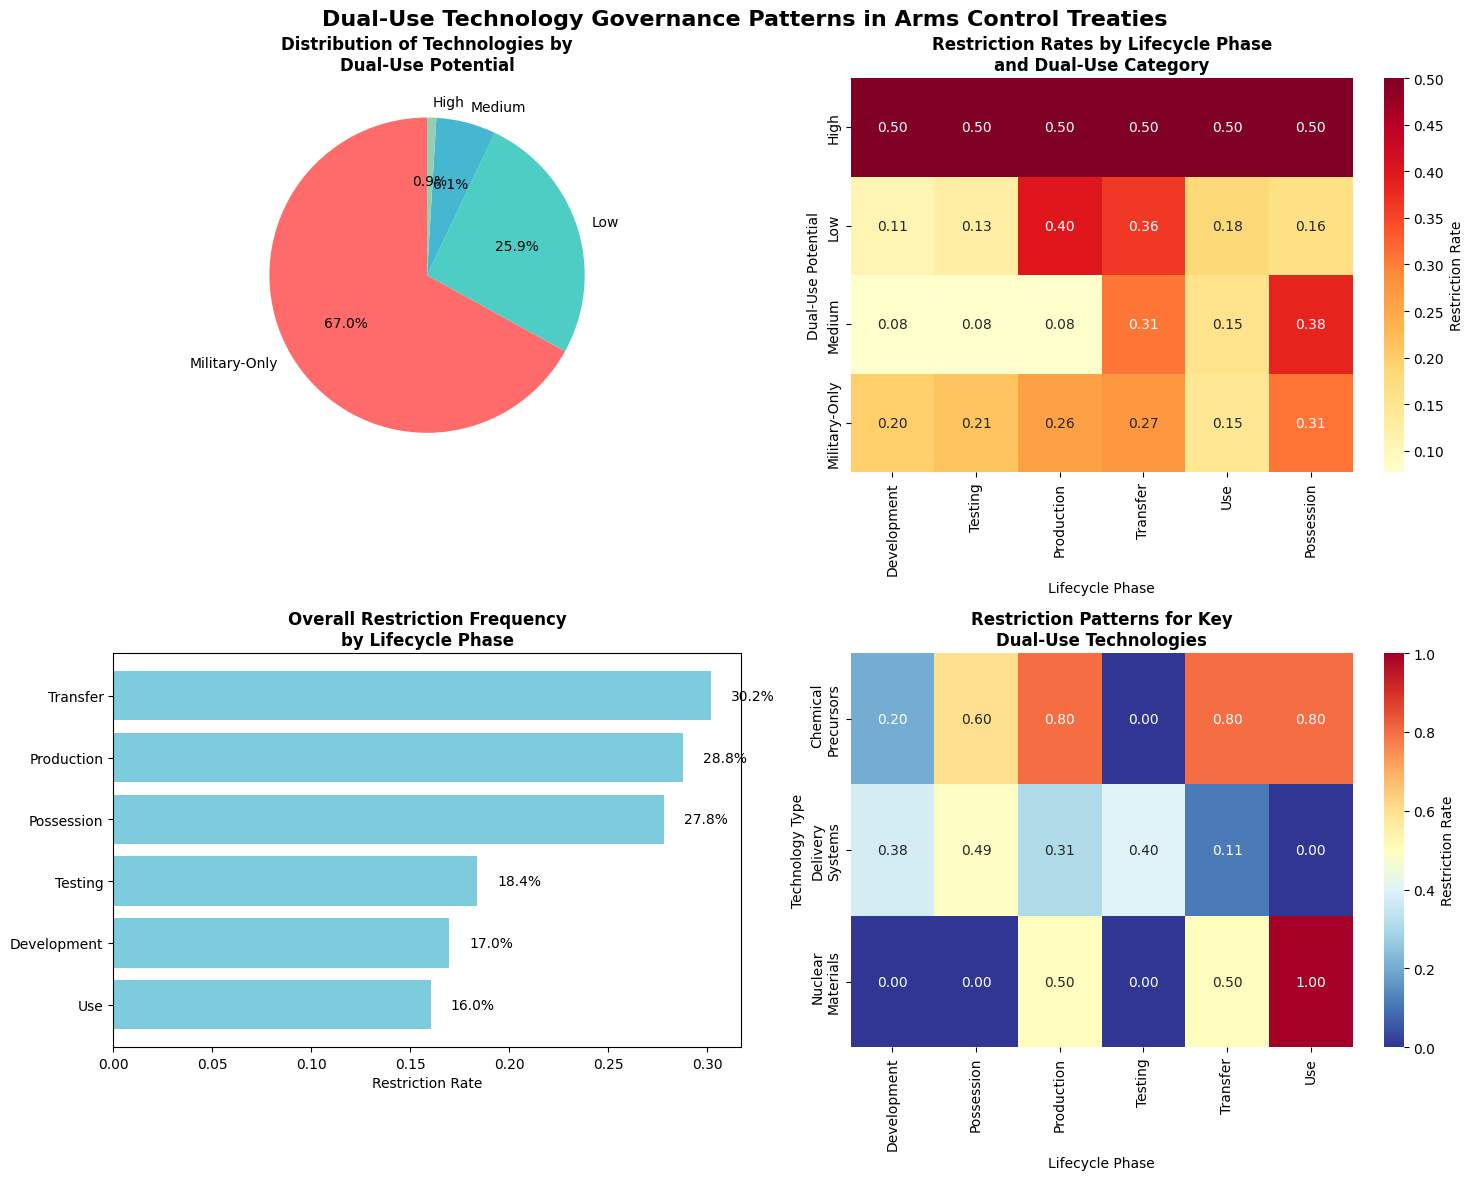

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Dual-Use Technology Governance Patterns in Arms Control Treaties', 
             fontsize=16, fontweight='bold')

# 1. Dual-Use Classification Distribution
ax1 = axes[0, 0]
dual_use_counts = weapons_df['dual_use_potential'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
wedges, texts, autotexts = ax1.pie(dual_use_counts.values, labels=dual_use_counts.index, 
                                   autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Distribution of Technologies by\nDual-Use Potential', fontweight='bold')

# 2. Lifecycle Phase Restrictions by Dual-Use Category
ax2 = axes[0, 1]
phase_cols = [f'{phase.lower()}_restricted' for phase in lifecycle_phases.keys()]
available_phase_cols = [col for col in phase_cols if col in weapons_df.columns]

if available_phase_cols:
    phase_analysis = weapons_df.groupby('dual_use_potential')[available_phase_cols].mean()
    
    # Clean up column names for display
    phase_analysis.columns = [col.replace('_restricted', '').title() for col in phase_analysis.columns]
    
    # Create heatmap
    sns.heatmap(phase_analysis, annot=True, fmt='.2f', cmap='YlOrRd', 
                ax=ax2, cbar_kws={'label': 'Restriction Rate'})
    ax2.set_title('Restriction Rates by Lifecycle Phase\nand Dual-Use Category', fontweight='bold')
    ax2.set_xlabel('Lifecycle Phase')
    ax2.set_ylabel('Dual-Use Potential')

# 3. Overall Lifecycle Phase Restriction Frequency
ax3 = axes[1, 0]
if available_phase_cols:
    overall_restrictions = weapons_df[available_phase_cols].mean().sort_values(ascending=True)
    phase_names = [col.replace('_restricted', '').title() for col in overall_restrictions.index]
    
    bars = ax3.barh(phase_names, overall_restrictions.values, color='#45B7D1', alpha=0.7)
    ax3.set_title('Overall Restriction Frequency\nby Lifecycle Phase', fontweight='bold')
    ax3.set_xlabel('Restriction Rate')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax3.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.1%}', ha='left', va='center')

# 4. Specific Technology Categories
ax4 = axes[1, 1]
specific_technologies = {
    'Chemical\nPrecursors': weapons_df['item'].str.contains('chemical|precursor', case=False, na=False),
    'Delivery\nSystems': weapons_df['item'].str.contains('delivery|missile|rocket|launcher', case=False, na=False),
    'Nuclear\nMaterials': weapons_df['item'].str.contains('uranium|plutonium|fissile|nuclear material', case=False, na=False)
}

tech_data = []
for tech_name, mask in specific_technologies.items():
    matching_items = weapons_df[mask]
    if len(matching_items) > 0 and available_phase_cols:
        tech_restrictions = matching_items[available_phase_cols].mean()
        for phase, rate in tech_restrictions.items():
            phase_name = phase.replace('_restricted', '').title()
            tech_data.append({'Technology': tech_name, 'Phase': phase_name, 'Restriction_Rate': rate})

if tech_data:
    tech_df = pd.DataFrame(tech_data)
    pivot_tech = tech_df.pivot(index='Technology', columns='Phase', values='Restriction_Rate')
    
    sns.heatmap(pivot_tech, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax4,
                cbar_kws={'label': 'Restriction Rate'})
    ax4.set_title('Restriction Patterns for Key\nDual-Use Technologies', fontweight='bold')
    ax4.set_xlabel('Lifecycle Phase')
    ax4.set_ylabel('Technology Type')

plt.tight_layout()
plt.savefig('dual_use_governance_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'dual_use_governance_analysis.png'")

Create a summary table

<p style="font-size:16pt;">DUAL-USE TECHNOLOGY GOVERNANCE ANALYSIS SUMMARY</p>
<p style="font-size:14pt;">KEY FINDINGS:</p>

Overall patterns

In [114]:
#it's already up in "key insights for AI governance"
if available_phase_cols:
    overall_restrictions = weapons_df[available_phase_cols].mean().sort_values(ascending=False)
    print(f"1. Most restricted phase: {overall_restrictions.idxmax().replace('_restricted', '').title()} ({overall_restrictions.max():.1%})")
    print(f"2. Least restricted phase: {overall_restrictions.idxmin().replace('_restricted', '').title()} ({overall_restrictions.min():.1%})")

1. Most restricted phase: Transfer (30.2%)
2. Least restricted phase: Use (16.0%)


Dual-use specific insights

In [115]:
high_dual_use = weapons_df[weapons_df['dual_use_potential'] == 'High']
military_only = weapons_df[weapons_df['dual_use_potential'] == 'Military-Only']

if len(high_dual_use) > 0 and len(military_only) > 0 and available_phase_cols:
    high_dual_avg = high_dual_use[available_phase_cols].mean().mean()
    military_avg = military_only[available_phase_cols].mean().mean()
    
    print(f"3. High dual-use technologies: {high_dual_avg:.1%} average restriction rate")
    print(f"4. Military-only technologies: {military_avg:.1%} average restriction rate")

3. High dual-use technologies: 50.0% average restriction rate
4. Military-only technologies: 23.4% average restriction rate


DUAL-USE TECHNOLOGY COUNTS:

In [116]:
for category, count in weapons_df['dual_use_potential'].value_counts().items():
    print(f"{category}: {count} technologies ({count/len(weapons_df)*100:.1f}%)")

Military-Only: 142 technologies (67.0%)
Low: 55 technologies (25.9%)
Medium: 13 technologies (6.1%)
High: 2 technologies (0.9%)


AI GOVERNANCE RECOMMENDATIONS:

<p>• Focus on later lifecycle phases (possession, production) for strongest precedent</p>
<p>• Consider graduated restrictions based on dual-use potential</p>
<p>• Transfer restrictions may be key for AI model sharing governance</p>
<p>• Development phase shows least restriction - preserve research freedom</p>
<p>• Use-phase restrictions common - relevant for AI deployment controls</p>
<p></p>
<p>FILE SAVED: dual_use_governance_analysis.png</p>
<p>This visualization can be included in your research presentation.</p>

<p style="font-size: 26pt;color:red;">Exploratory analysis</p>

Group by weapon type and count:

0. Weapons & ammunition
1. Facility
2. Materials/components
3. Other
4. Interceptor missiles, launchers and radars

In [117]:
weapons_groupby_type_df = weapons_df.groupby(['item_type']).size()
weapons_groupby_type_df 

item_type
0.0     40
1.0    141
2.0     11
3.0     16
4.0      4
dtype: int64

Count how many times each weapon appears in the merged dataset (how many different treaties regulate each weapon?)

In [118]:
weapons_groupby_item_df = merged_df 
weapons_groupby_item_df['item'] = weapons_groupby_item_df['item'].str.strip()
pd.options.display.max_rows = 500 
weapons_groupby_item_df['item'].value_counts()

item
nuclear weapon                                                                                              19
weapons general                                                                                              9
fissile material                                                                                             7
nuclear explosive devise                                                                                     7
radioactive waste                                                                                            6
small arms and light weapon                                                                                  6
icbm                                                                                                         5
icbm launcher                                                                                                5
slbm                                                                                                       

Select only those items which have had one of its life cycle stages banned

In [119]:
ban_columns = ['ban_development', 'ban_testing', 'ban_production', 'ban_acquisition', 'ban_possession', 'ban_transfer', 'ban_station', 'ban_use', 'ban_disposal']
weapons_banned_df = weapons_df[weapons_df[ban_columns].any(axis=1)]

<p>Select only those items which have had one of its life cycle stages restricted</p>
<p>!!!! Restrictions on stationing aren't listed in the csv file (no column named restriction_stationing)</p>

In [120]:
restriction_columns = ['restriction_development', 'testing_restriction', 'restriction_production', 'restriction_acquisition', 'restriction_possession', 'restriction_transfer', 'restriction_use', 'restriction_disposal']
weapons_restricted_df = weapons_df[weapons_df[restriction_columns].any(axis=1)]

Select only weapons

In [121]:
weapons_onlyweapons_df = weapons_df[weapons_df['item_type'] == 1]

Life cyle stages filter

In [122]:
cols_to_keep = [
    # Identifiers
    'item_type', 'item',

    # Lifecycle stages - ban flags
    'ban_development',
    'ban_testing',
    'ban_production',
    'ban_acquisition',
    'ban_possession',
    'ban_station',
    'ban_transfer',
    'ban_use',
    'ban_disposal',

    # Lifecycle stages - restriction flags
    'restriction_development',
    'testing_restriction',       # note: inconsistent naming in the dataset
    'restriction_production',
    'restriction_acquisition',
    'restriction_possession',
    'restriction_transfer',
    'restriction_use',
    'restriction_disposal',

    # End-of-life stages (no ban/restriction equivalents)
    'eliminitation',             # note: typo in the dataset
    'conversion',
    'modernization',
    'facility_destruction',
]

weapons_lifecycle_filtered_df = weapons_df[cols_to_keep]
weapons_lifecycle_filtered_df.sample(10)

,item_type,item,ban_development,ban_testing,ban_production,ban_acquisition,ban_possession,ban_station,ban_transfer,ban_use,...,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal,eliminitation,conversion,modernization,facility_destruction
90,1.0,automatic or semi-automatic rapid reload syste...,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0.0,NaN
13,3.0,toxin,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,2.0,NaN
10,1.0,submarine,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,2.0,NaN
45,3.0,parts and component,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,2.0,NaN
143,1.0,silos used as a launch control center,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,NaN
159,2.0,non-abm system,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.0
53,3.0,schedule 2 chemical,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,2.0,NaN
150,1.0,aicrafts not intially constructed as bombers (...,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0.0,NaN
181,0.0,carbine,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0.0,0.0
188,0.0,light trench mortar,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0.0,0.0


<p style="font-size:16pt;">Test correlations:</p>

Separate ban and restriction columns

In [123]:
ban_cols = [c for c in weapons_lifecycle_filtered_df.columns if c.startswith('ban_')]
restriction_cols = [c for c in weapons_lifecycle_filtered_df.columns if 'restriction' in c]

# Correlation between every ban col vs every restriction col
corr_matrix = weapons_lifecycle_filtered_df[ban_cols + restriction_cols].corr()

# Slice to only show ban vs restriction (not ban vs ban or restriction vs restriction)
corr_ban_vs_restriction = corr_matrix.loc[ban_cols, restriction_cols]
print(corr_ban_vs_restriction)

                 restriction_development  testing_restriction  \
ban_development                -0.089162            -0.093453   
ban_testing                    -0.092761            -0.097226   
ban_production                 -0.109454            -0.063520   
ban_acquisition                -0.144369            -0.151318   
ban_possession                       NaN                  NaN   
ban_station                    -0.041795            -0.043806   
ban_transfer                    0.024615             0.013531   
ban_use                        -0.069082            -0.072407   
ban_disposal                   -0.024016            -0.025171   

                 restriction_production  restriction_acquisition  \
ban_development               -0.128925                -0.103770   
ban_testing                   -0.134129                -0.107958   
ban_production                -0.117199                -0.127386   
ban_acquisition                0.256047                -0.168022   
ban_posse

Flattened into a ranked list:

In [124]:
# Stack matrix into a series and sort
corr_ranked = (
    corr_ban_vs_restriction
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'ban', 'level_1': 'restriction', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
)

print(corr_ranked.head(40))

                ban              restriction  correlation
26  ban_acquisition   restriction_production     0.256047
48     ban_transfer  restriction_development     0.024615
49     ban_transfer      testing_restriction     0.013531
71     ban_disposal     restriction_disposal    -0.004739
47      ban_station     restriction_disposal    -0.008248
63          ban_use     restriction_disposal    -0.013633
7   ban_development     restriction_disposal    -0.017596
15      ban_testing     restriction_disposal    -0.018306
23   ban_production     restriction_disposal    -0.021600
64     ban_disposal  restriction_development    -0.024016
55     ban_transfer     restriction_disposal    -0.024016
65     ban_disposal      testing_restriction    -0.025171
70     ban_disposal          restriction_use    -0.025739
67     ban_disposal  restriction_acquisition    -0.027950
31  ban_acquisition     restriction_disposal    -0.028491
29  ban_acquisition     restriction_transfer    -0.033641
69     ban_dis

Pearson - default, fine for binary

In [125]:
weapons_lifecycle_filtered_df[ban_cols + restriction_cols].corr(method='pearson')

,ban_development,ban_testing,ban_production,ban_acquisition,ban_possession,ban_station,ban_transfer,ban_use,ban_disposal,restriction_development,testing_restriction,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal
ban_development,1.000000,0.486201,0.539282,0.005512,NaN,-0.030622,0.226930,0.362088,-0.017596,-0.089162,-0.093453,-0.128925,-0.103770,-0.114848,-0.125152,-0.095560,-0.017596
ban_testing,0.486201,1.000000,0.648005,-0.056291,NaN,0.128949,-0.092761,0.047016,-0.018306,-0.092761,-0.097226,-0.134129,-0.107958,-0.165125,-0.130204,-0.099417,-0.018306
ban_production,0.539282,0.648005,1.000000,0.057098,NaN,0.102222,0.156041,0.284507,-0.021600,-0.109454,-0.063520,-0.117199,-0.127386,-0.157993,-0.153636,-0.117308,-0.021600
ban_acquisition,0.005512,-0.056291,0.057098,1.000000,NaN,0.063444,0.327817,0.058161,-0.028491,-0.144369,-0.151318,0.256047,-0.168022,-0.256993,-0.033641,-0.154729,-0.028491
ban_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ban_station,-0.030622,0.128949,0.102222,0.063444,NaN,1.000000,-0.041795,-0.023726,-0.008248,-0.041795,-0.043806,-0.060434,-0.048642,-0.074399,-0.058665,-0.044794,-0.008248
ban_transfer,0.226930,-0.092761,0.156041,0.327817,NaN,-0.041795,1.000000,0.249295,-0.024016,0.024615,0.013531,-0.175964,-0.141631,-0.081255,-0.170815,-0.084188,-0.024016
ban_use,0.362088,0.047016,0.284507,0.058161,NaN,-0.023726,0.249295,1.000000,-0.013633,-0.069082,-0.072407,-0.099890,-0.080400,-0.067739,-0.096967,-0.074039,-0.013633
ban_disposal,-0.017596,-0.018306,-0.021600,-0.028491,NaN,-0.008248,-0.024016,-0.013633,1.000000,-0.024016,-0.025171,-0.034726,-0.027950,-0.042750,-0.033710,-0.025739,-0.004739
restriction_development,-0.089162,-0.092761,-0.109454,-0.144369,NaN,-0.041795,0.024615,-0.069082,-0.024016,1.000000,0.201641,0.050352,-0.098115,0.020274,-0.017208,-0.130426,-0.024016


Spearman - better for ordinal/binary data, more robust

In [126]:
weapons_lifecycle_filtered_df[ban_cols + restriction_cols].corr(method='spearman')

,ban_development,ban_testing,ban_production,ban_acquisition,ban_possession,ban_station,ban_transfer,ban_use,ban_disposal,restriction_development,testing_restriction,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal
ban_development,1.000000,0.486201,0.539282,0.005512,NaN,-0.030622,0.226930,0.362088,-0.017596,-0.089162,-0.093453,-0.128925,-0.103770,-0.114848,-0.125152,-0.095560,-0.017596
ban_testing,0.486201,1.000000,0.648005,-0.056291,NaN,0.128949,-0.092761,0.047016,-0.018306,-0.092761,-0.097226,-0.134129,-0.107958,-0.165125,-0.130204,-0.099417,-0.018306
ban_production,0.539282,0.648005,1.000000,0.057098,NaN,0.102222,0.156041,0.284507,-0.021600,-0.109454,-0.063520,-0.117199,-0.127386,-0.157993,-0.153636,-0.117308,-0.021600
ban_acquisition,0.005512,-0.056291,0.057098,1.000000,NaN,0.063444,0.327817,0.058161,-0.028491,-0.144369,-0.151318,0.256047,-0.168022,-0.256993,-0.033641,-0.154729,-0.028491
ban_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ban_station,-0.030622,0.128949,0.102222,0.063444,NaN,1.000000,-0.041795,-0.023726,-0.008248,-0.041795,-0.043806,-0.060434,-0.048642,-0.074399,-0.058665,-0.044794,-0.008248
ban_transfer,0.226930,-0.092761,0.156041,0.327817,NaN,-0.041795,1.000000,0.249295,-0.024016,0.024615,0.013531,-0.175964,-0.141631,-0.081255,-0.170815,-0.084188,-0.024016
ban_use,0.362088,0.047016,0.284507,0.058161,NaN,-0.023726,0.249295,1.000000,-0.013633,-0.069082,-0.072407,-0.099890,-0.080400,-0.067739,-0.096967,-0.074039,-0.013633
ban_disposal,-0.017596,-0.018306,-0.021600,-0.028491,NaN,-0.008248,-0.024016,-0.013633,1.000000,-0.024016,-0.025171,-0.034726,-0.027950,-0.042750,-0.033710,-0.025739,-0.004739
restriction_development,-0.089162,-0.092761,-0.109454,-0.144369,NaN,-0.041795,0.024615,-0.069082,-0.024016,1.000000,0.201641,0.050352,-0.098115,0.020274,-0.017208,-0.130426,-0.024016


<p style="font-size: 26pt;color:red;">Facilities analysis</p>

In [127]:
facilities_df = weapons_df[weapons_df['item_type'] == 1]

Which columns are causing problems due to no variance?

In [128]:
facilities_lifecycle_df = facilities_df[cols_to_keep]

ban_cols = [c for c in facilities_lifecycle_df.columns if c.startswith('ban_')]
restriction_cols = [c for c in facilities_lifecycle_df.columns if 'restriction' in c]

flag_cols = ban_cols + restriction_cols

for col in flag_cols:
    unique_vals = facilities_lifecycle_df[col].dropna().unique()
    if len(unique_vals) <= 1:
        print(f"{col}: only contains {unique_vals}")

ban_possession: only contains [0]
ban_disposal: only contains [0]
restriction_disposal: only contains [0]


Testing correlations between different life cycle stages

In [129]:
# Separate ban and restriction columns
ban_cols = [c for c in facilities_lifecycle_df.columns if c.startswith('ban_')]
restriction_cols = [c for c in facilities_lifecycle_df.columns if 'restriction' in c]

# Correlation between every ban col vs every restriction col
corr_matrix = facilities_lifecycle_df[ban_cols + restriction_cols].corr()

# Slice to only show ban vs restriction (not ban vs ban or restriction vs restriction)
corr_ban_vs_restriction = corr_matrix.loc[ban_cols, restriction_cols]
print(corr_ban_vs_restriction)

                 restriction_development  testing_restriction  \
ban_development                -0.127589            -0.123999   
ban_testing                    -0.138893            -0.134985   
ban_production                 -0.154893            -0.088107   
ban_acquisition                -0.050180            -0.048767   
ban_possession                       NaN                  NaN   
ban_station                    -0.061679            -0.059944   
ban_transfer                    0.117231             0.125245   
ban_use                        -0.088192            -0.085710   
ban_disposal                         NaN                  NaN   

                 restriction_production  restriction_acquisition  \
ban_development               -0.123999                -0.123999   
ban_testing                   -0.134985                -0.134985   
ban_production                -0.088107                -0.150534   
ban_acquisition               -0.048767                -0.048767   
ban_posse

In [130]:
corr_ranked = (
    corr_ban_vs_restriction
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'ban', 'level_1': 'restriction', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
)

print(corr_ranked.head(40))

                ban              restriction  correlation
49     ban_transfer      testing_restriction     0.125245
48     ban_transfer  restriction_development     0.117231
52     ban_transfer   restriction_possession     0.013755
54     ban_transfer          restriction_use    -0.033137
29  ban_acquisition     restriction_transfer    -0.047337
30  ban_acquisition          restriction_use    -0.048767
26  ban_acquisition   restriction_production    -0.048767
25  ban_acquisition      testing_restriction    -0.048767
27  ban_acquisition  restriction_acquisition    -0.048767
24  ban_acquisition  restriction_development    -0.050180
45      ban_station     restriction_transfer    -0.058186
46      ban_station          restriction_use    -0.059944
41      ban_station      testing_restriction    -0.059944
42      ban_station   restriction_production    -0.059944
43      ban_station  restriction_acquisition    -0.059944
40      ban_station  restriction_development    -0.061679
61          ba

Pearson - default, fine for binary

In [131]:
facilities_lifecycle_df[ban_cols + restriction_cols].corr(method='pearson')

,ban_development,ban_testing,ban_production,ban_acquisition,ban_possession,ban_station,ban_transfer,ban_use,ban_disposal,restriction_development,testing_restriction,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal
ban_development,1.000000,0.493665,0.511507,0.178352,NaN,-0.044969,0.311790,0.313458,NaN,-0.127589,-0.123999,-0.123999,-0.123999,-0.184222,-0.120363,-0.123999,NaN
ban_testing,0.493665,1.000000,0.678209,0.160727,NaN,0.115390,-0.091733,0.047497,NaN,-0.138893,-0.134985,-0.134985,-0.134985,-0.257667,-0.131026,-0.134985,NaN
ban_production,0.511507,0.678209,1.000000,0.323962,NaN,0.096340,0.152247,0.245656,NaN,-0.154893,-0.088107,-0.088107,-0.150534,-0.242381,-0.146120,-0.150534,NaN
ban_acquisition,0.178352,0.160727,0.323962,1.000000,NaN,0.397934,0.200506,0.271847,NaN,-0.050180,-0.048767,-0.048767,-0.048767,-0.093090,-0.047337,-0.048767,NaN
ban_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ban_station,-0.044969,0.115390,0.096340,0.397934,NaN,1.000000,-0.040737,-0.031083,NaN,-0.061679,-0.059944,-0.059944,-0.059944,-0.114424,-0.058186,-0.059944,NaN
ban_transfer,0.311790,-0.091733,0.152247,0.200506,NaN,-0.040737,1.000000,0.352394,NaN,0.117231,0.125245,-0.112328,-0.112328,0.013755,-0.109034,-0.033137,NaN
ban_use,0.313458,0.047497,0.245656,0.271847,NaN,-0.031083,0.352394,1.000000,NaN,-0.088192,-0.085710,-0.085710,-0.085710,-0.091065,-0.083197,-0.085710,NaN
ban_disposal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restriction_development,-0.127589,-0.138893,-0.154893,-0.050180,NaN,-0.061679,0.117231,-0.088192,NaN,1.000000,0.115408,0.058312,-0.112979,-0.119009,-0.048409,-0.170075,NaN


Spearman - better for ordinal/binary data, more robust

In [132]:
facilities_lifecycle_df[ban_cols + restriction_cols].corr(method='spearman')

,ban_development,ban_testing,ban_production,ban_acquisition,ban_possession,ban_station,ban_transfer,ban_use,ban_disposal,restriction_development,testing_restriction,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal
ban_development,1.000000,0.493665,0.511507,0.178352,NaN,-0.044969,0.311790,0.313458,NaN,-0.127589,-0.123999,-0.123999,-0.123999,-0.184222,-0.120363,-0.123999,NaN
ban_testing,0.493665,1.000000,0.678209,0.160727,NaN,0.115390,-0.091733,0.047497,NaN,-0.138893,-0.134985,-0.134985,-0.134985,-0.257667,-0.131026,-0.134985,NaN
ban_production,0.511507,0.678209,1.000000,0.323962,NaN,0.096340,0.152247,0.245656,NaN,-0.154893,-0.088107,-0.088107,-0.150534,-0.242381,-0.146120,-0.150534,NaN
ban_acquisition,0.178352,0.160727,0.323962,1.000000,NaN,0.397934,0.200506,0.271847,NaN,-0.050180,-0.048767,-0.048767,-0.048767,-0.093090,-0.047337,-0.048767,NaN
ban_possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ban_station,-0.044969,0.115390,0.096340,0.397934,NaN,1.000000,-0.040737,-0.031083,NaN,-0.061679,-0.059944,-0.059944,-0.059944,-0.114424,-0.058186,-0.059944,NaN
ban_transfer,0.311790,-0.091733,0.152247,0.200506,NaN,-0.040737,1.000000,0.352394,NaN,0.117231,0.125245,-0.112328,-0.112328,0.013755,-0.109034,-0.033137,NaN
ban_use,0.313458,0.047497,0.245656,0.271847,NaN,-0.031083,0.352394,1.000000,NaN,-0.088192,-0.085710,-0.085710,-0.085710,-0.091065,-0.083197,-0.085710,NaN
ban_disposal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restriction_development,-0.127589,-0.138893,-0.154893,-0.050180,NaN,-0.061679,0.117231,-0.088192,NaN,1.000000,0.115408,0.058312,-0.112979,-0.119009,-0.048409,-0.170075,NaN
